# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 2. Load Preprocessed Dataset

In [3]:
X_train = np.load("dyslexia_preprocessed/train/X.npy")
y_train = np.load("dyslexia_preprocessed/train/y.npy")

X_val = np.load("dyslexia_preprocessed/val/X.npy")
y_val = np.load("dyslexia_preprocessed/val/y.npy")

test = np.load("dyslexia_preprocessed/test.npz")

X_test = test["X"]
y_test = test["y"]

print("Data loaded successfully!")

Data loaded successfully!


# 3. Inspect Dataset

In [4]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (122175, 32, 32)
y_train: (122175,)
X_val: (26181, 32, 32)
y_val: (26181,)
X_test: (26181, 32, 32)
y_test: (26181,)


In [5]:
print("Training labels:", np.unique(y_train))
print("Validation labels:", np.unique(y_val))
print("Test labels:", np.unique(y_test))

Training labels: [0 1 2]
Validation labels: [0 1 2]
Test labels: [0 1 2]


# 4. Visualize Images

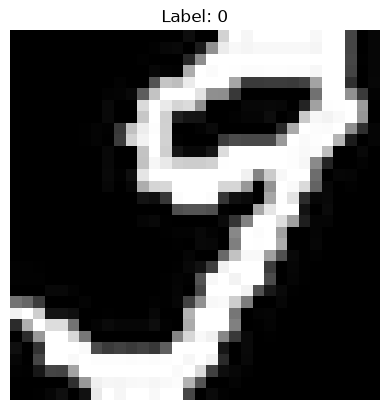

In [6]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

# 5. Prepare Data for CNN

In [7]:
X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 32, 32, 1)
X_val = X_val.reshape(-1, 32, 32, 1)
X_test = X_test.reshape(-1, 32, 32, 1)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (122175, 32, 32, 1)
X_val: (26181, 32, 32, 1)
X_test: (26181, 32, 32, 1)


# 6. Build CNN

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(3, activation="softmax")
])

model.summary()

e:\PS Project\cnn_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,723 (620.01 KB)

 Trainable params: 158,723 (620.01 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Compile CNN

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


# 8. Train CNN

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - accuracy: 0.8267 - loss: 0.4277 - val_accuracy: 0.8851 - val_loss: 0.2939
Epoch 2/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.9056 - loss: 0.2468 - val_accuracy: 0.9153 - val_loss: 0.2220
Epoch 3/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 70s 18ms/step - accuracy: 0.9282 - loss: 0.1906 - val_accuracy: 0.9369 - val_loss: 0.1634
Epoch 4/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 65s 17ms/step - accuracy: 0.9402 - loss: 0.1572 - val_accuracy: 0.9403 - val_loss: 0.1592
Epoch 5/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 126s 33ms/step - accuracy: 0.9482 - loss: 0.1362 - val_accuracy: 0.9466 - val_loss: 0.1443
Epoch 6/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 89s 23ms/step - accuracy: 0.9535 - loss: 0.1213 - val_accuracy: 0.9455 - val_loss: 0.1501
Epoch 7/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.9579 - loss: 0.1087 - val_accuracy: 0.9469 - val_loss: 0.1535
Epoch 8/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 74s 19ms/step - accuracy: 0.9618 - 

# 9. Evaluate CNN

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9491 - loss: 0.1579
Test Loss: 0.15793174505233765
Test Accuracy: 0.9490852355957031


# 10. Feature Extraction

In [13]:
feature_extractor = tf.keras.Sequential(model.layers[:-2])

train_features = feature_extractor.predict(X_train)
val_features = feature_extractor.predict(X_val)
test_features = feature_extractor.predict(X_test)

print("Train:", train_features.shape)
print("Validation:", val_features.shape)
print("Test:", test_features.shape)

3818/3818 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
Train: (122175, 128)
Validation: (26181, 128)
Test: (26181, 128)


# 11. Save Features

In [14]:
np.save("train_features.npy", train_features)
np.save("val_features.npy", val_features)
np.save("test_features.npy", test_features)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("Features saved successfully!")

Features saved successfully!
